# Logistic Regression: How It Works

This notebook introduces logistic regression with a public binary classification dataset from `scikit-learn`.

Dataset: Breast Cancer Wisconsin Diagnostic dataset. We predict whether a tumor is **malignant** (`1`) or **benign** (`0`).

We will cover:

- how logistic regression turns a linear score into a probability;
- why feature scaling is useful for logistic regression;
- how to train and inspect a logistic regression model;
- why accuracy can be misleading on imbalanced binary classification;
- why F1 is a stronger default metric for almost all practical binary classification problems where the positive class matters;
- how changing the probability threshold changes precision, recall, F1, and accuracy.

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

plt.rcParams.update({
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "figure.figsize": (9, 5),
})

pd.set_option("display.max_columns", 40)

RANDOM_STATE = 42

## 1. The Basic Idea

Linear regression predicts an unbounded number. Logistic regression predicts a probability for a binary class.

First, it learns a linear score:

$$z = b_0 + b_1x_1 + b_2x_2 + \dots + b_nx_n$$

Then it passes that score through the sigmoid function:

$$P(y=1 \mid x) = \frac{1}{1 + e^{-z}}$$

The sigmoid maps any score to a value between `0` and `1`, so we can interpret the output as a probability. By default, `scikit-learn` predicts class `1` when the probability is at least `0.5`.

## 2. Load a Public Binary Classification Dataset

`load_breast_cancer` is a public dataset bundled with `scikit-learn`. The original target uses `0 = malignant` and `1 = benign`.

For this notebook we recode the target so that:

- `1` means **malignant**, the positive class we care about detecting;
- `0` means **benign**.

In [14]:
cancer = load_breast_cancer(as_frame=True)
raw_df = cancer.frame.copy()

X_full = raw_df.drop(columns="target")
y_full = (raw_df["target"] == 0).astype(int)

label_names = {0: "benign", 1: "malignant"}

original_balance = (
    y_full.map(label_names)
    .value_counts()
    .rename_axis("class")
    .to_frame("count")
)
original_balance["share"] = (original_balance["count"] / len(y_full)).round(3)

print(f"Rows: {len(raw_df)}")
print(f"Features: {X_full.shape[1]}")
print(f"Original sklearn target names: {list(cancer.target_names)}")

display(original_balance)
X_full.head()

Rows: 569
Features: 30
Original sklearn target names: ['malignant', 'benign']


,count,share
class,,
benign,357,0.627
malignant,212,0.373


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 3. Make the Positive Class Rare

The original dataset is only moderately imbalanced. To make the metric problem visible, we keep all benign examples and take a reproducible sample of malignant examples.

This simulates a common binary classification setting: the event we care about is the minority class.

In [15]:
rng = np.random.default_rng(RANDOM_STATE)
N_MALIGNANT = 60

malignant_idx = y_full[y_full == 1].index.to_numpy()
benign_idx = y_full[y_full == 0].index.to_numpy()

sampled_malignant_idx = rng.choice(malignant_idx, size=N_MALIGNANT, replace=False)
selected_idx = np.concatenate([benign_idx, sampled_malignant_idx])

X = X_full.loc[selected_idx].sort_index()
y = y_full.loc[selected_idx].sort_index()

class_balance = (
    y.map(label_names)
    .value_counts()
    .rename_axis("class")
    .to_frame("count")
)
class_balance["share"] = (class_balance["count"] / len(y)).round(3)

class_balance

,count,share
class,,
benign,357,0.856
malignant,60,0.144


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE,
)

split_balance = pd.concat(
    [
        y_train.map(label_names).value_counts().rename("train"),
        y_test.map(label_names).value_counts().rename("test"),
    ],
    axis=1,
).fillna(0).astype(int)

print(f"Training rows: {len(X_train)}")
print(f"Test rows: {len(X_test)}")

display(split_balance)

Training rows: 312
Test rows: 105


,train,test
target,,
benign,267,90
malignant,45,15


## 4. Visualize the Sigmoid with One Feature

A one-feature model is useful for seeing the shape of logistic regression. Here the model uses only `mean radius`, then learns an S-shaped probability curve.

The real model later will use all features.

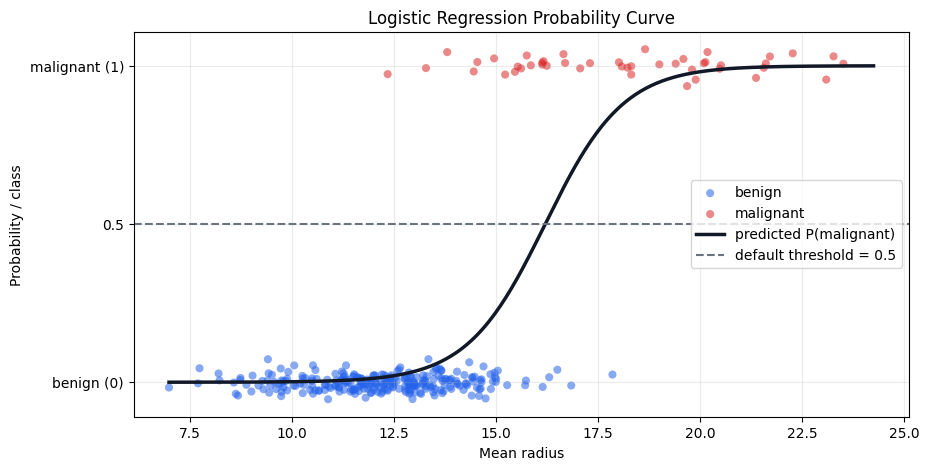

In [17]:
single_feature = ["mean radius"]

single_feature_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
)
single_feature_model.fit(X_train[single_feature], y_train)

radius_grid = np.linspace(
    X[single_feature[0]].min(),
    X[single_feature[0]].max(),
    400,
).reshape(-1, 1)
radius_grid_df = pd.DataFrame(radius_grid, columns=single_feature)
prob_grid = single_feature_model.predict_proba(radius_grid_df)[:, 1]

fig, ax = plt.subplots(figsize=(10, 5))
jitter_rng = np.random.default_rng(RANDOM_STATE)

for class_value, class_name, color in [
    (0, "benign", "#2563EB"),
    (1, "malignant", "#DC2626"),
]:
    mask = y_train == class_value
    jitter = jitter_rng.normal(0, 0.025, size=mask.sum())
    ax.scatter(
        X_train.loc[mask, single_feature[0]],
        y_train.loc[mask] + jitter,
        s=34,
        alpha=0.55,
        color=color,
        edgecolor="none",
        label=class_name,
    )

ax.plot(radius_grid.ravel(), prob_grid, color="#111827", linewidth=2.5, label="predicted P(malignant)")
ax.axhline(0.5, color="#6B7280", linestyle="--", linewidth=1.5, label="default threshold = 0.5")
ax.set_title("Logistic Regression Probability Curve")
ax.set_xlabel("Mean radius")
ax.set_ylabel("Probability / class")
ax.set_yticks([0, 0.5, 1])
ax.set_yticklabels(["benign (0)", "0.5", "malignant (1)"])
ax.legend(loc="center right")
plt.show()

## 5. Train a Logistic Regression Pipeline

Feature values in this dataset have different scales. Logistic regression is easier to optimize and interpret when features are standardized first.

The pipeline below applies:

1. `StandardScaler` to center and scale the features;
2. `LogisticRegression` to learn the classification model.

In [18]:
logistic_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
)

logistic_model.fit(X_train, y_train)

y_proba = logistic_model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

print("First 10 predicted probabilities for the malignant class:")
pd.Series(y_proba[:10], name="P(malignant)").round(3).to_frame()

First 10 predicted probabilities for the malignant class:


,P(malignant)
0,0.001
1,0.002
2,0.001
3,0.000
4,0.000
5,0.065
6,0.000
7,0.000
8,0.045
9,0.053


Largest coefficients after standardization:


,feature,coefficient,abs_coefficient
20,worst radius,0.882238,0.882238
21,worst texture,0.865718,0.865718
23,worst area,0.787399,0.787399
22,worst perimeter,0.746038,0.746038
7,mean concave points,0.698298,0.698298
11,texture error,-0.637898,0.637898
6,mean concavity,0.548959,0.548959
28,worst symmetry,0.525412,0.525412
13,area error,0.511920,0.511920
10,radius error,0.500054,0.500054


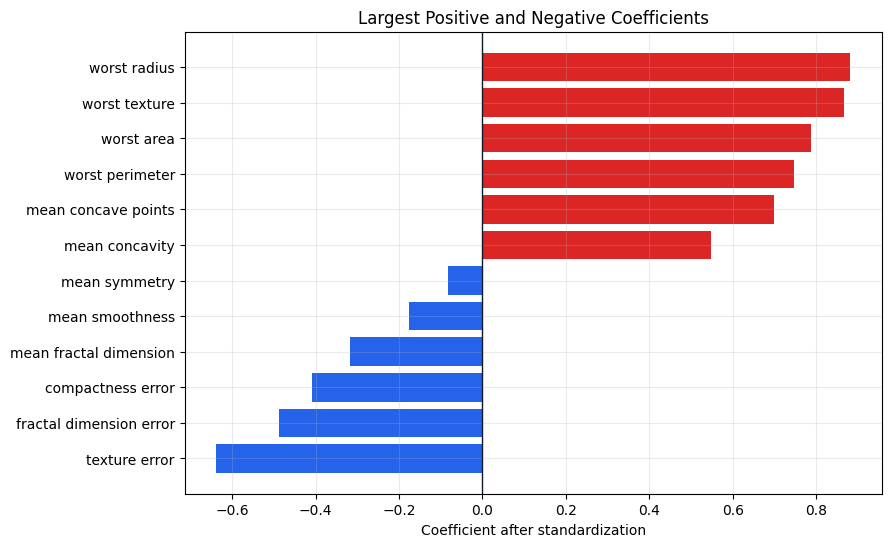

In [19]:
log_reg_step = logistic_model.named_steps["logisticregression"]

coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": log_reg_step.coef_[0],
})
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coefficient", ascending=False)

print("Largest coefficients after standardization:")
display(coef_df.head(10))

top_signed_coef = pd.concat([
    coef_df.nsmallest(6, "coefficient"),
    coef_df.nlargest(6, "coefficient"),
]).sort_values("coefficient")

fig, ax = plt.subplots(figsize=(9, 6))
colors = np.where(top_signed_coef["coefficient"] > 0, "#DC2626", "#2563EB")
ax.barh(top_signed_coef["feature"], top_signed_coef["coefficient"], color=colors)
ax.axvline(0, color="#111827", linewidth=1)
ax.set_title("Largest Positive and Negative Coefficients")
ax.set_xlabel("Coefficient after standardization")
plt.show()

A positive coefficient increases the log-odds of the malignant class. A negative coefficient decreases them.

Because the model is trained after standardization, these coefficients are measured in standard-deviation units rather than the original feature units.

## 6. The Accuracy Trap

Accuracy answers: **what share of all predictions are correct?**

That sounds reasonable, but it can fail badly when one class is much more common. A classifier that always predicts the majority class can get high accuracy while completely missing the class we care about.

F1 is usually a better default for binary classification when the positive class matters, because it combines precision and recall:

$$F1 = 2 \cdot \frac{precision \cdot recall}{precision + recall}$$

Unlike accuracy, F1 does not reward a model for collecting many easy true negatives while ignoring positives.

In [20]:
def evaluate_predictions(model_name, y_true, y_pred):
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "predicted_malignant": int(np.sum(y_pred == 1)),
    }


majority_model = DummyClassifier(strategy="most_frequent")
majority_model.fit(X_train, y_train)
majority_pred = majority_model.predict(X_test)

metric_table = pd.DataFrame([
    evaluate_predictions("Always predict benign", y_test, majority_pred),
    evaluate_predictions("Logistic regression", y_test, y_pred),
]).set_index("model")

metric_table.round(3)

,accuracy,precision,recall,f1,predicted_malignant
model,,,,,
Always predict benign,0.857,0.0,0.0,0.000,0
Logistic regression,0.971,1.0,0.8,0.889,12


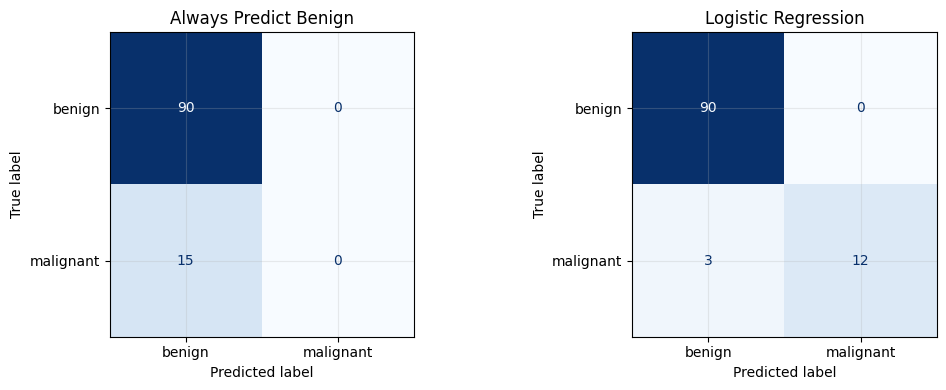

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    majority_pred,
    display_labels=["benign", "malignant"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0],
)
axes[0].set_title("Always Predict Benign")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["benign", "malignant"],
    cmap="Blues",
    colorbar=False,
    ax=axes[1],
)
axes[1].set_title("Logistic Regression")

fig.tight_layout()
plt.show()

The majority classifier looks decent by accuracy because most test rows are benign. But it predicts zero malignant cases, so precision, recall, and F1 are all `0`.

This is why accuracy alone is a risky metric for binary classification. It can hide the exact failure mode the model was built to solve.

## 7. Thresholds: Accuracy and F1 Can Prefer Different Behavior

The default threshold is `0.5`, but it is not special. If the goal is to detect the positive class, a lower threshold may improve recall and F1.

To make the trade-off easy to see, this section uses a smaller logistic regression model with only three interpretable features.

In [22]:
simple_features = ["mean radius", "mean texture", "mean smoothness"]

threshold_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
)
threshold_model.fit(X_train[simple_features], y_train)
threshold_proba = threshold_model.predict_proba(X_test[simple_features])[:, 1]

threshold_rows = []
for threshold in np.linspace(0.01, 0.99, 99):
    threshold_pred = (threshold_proba >= threshold).astype(int)
    threshold_rows.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, threshold_pred),
        "precision": precision_score(y_test, threshold_pred, zero_division=0),
        "recall": recall_score(y_test, threshold_pred, zero_division=0),
        "f1": f1_score(y_test, threshold_pred, zero_division=0),
        "predicted_malignant": int(np.sum(threshold_pred == 1)),
    })

threshold_metrics = pd.DataFrame(threshold_rows)
best_accuracy_row = threshold_metrics.loc[threshold_metrics["accuracy"].idxmax()]
best_f1_row = threshold_metrics.loc[threshold_metrics["f1"].idxmax()]
default_row = threshold_metrics.iloc[(threshold_metrics["threshold"] - 0.5).abs().argmin()]

threshold_summary = pd.DataFrame(
    [default_row, best_accuracy_row, best_f1_row],
    index=["default threshold", "best accuracy", "best F1"],
)

threshold_summary.round(3)

,threshold,accuracy,precision,recall,f1,predicted_malignant
default threshold,0.50,0.943,0.909,0.667,0.769,11.0
best accuracy,0.52,0.952,1.000,0.667,0.800,10.0
best F1,0.16,0.943,0.737,0.933,0.824,19.0


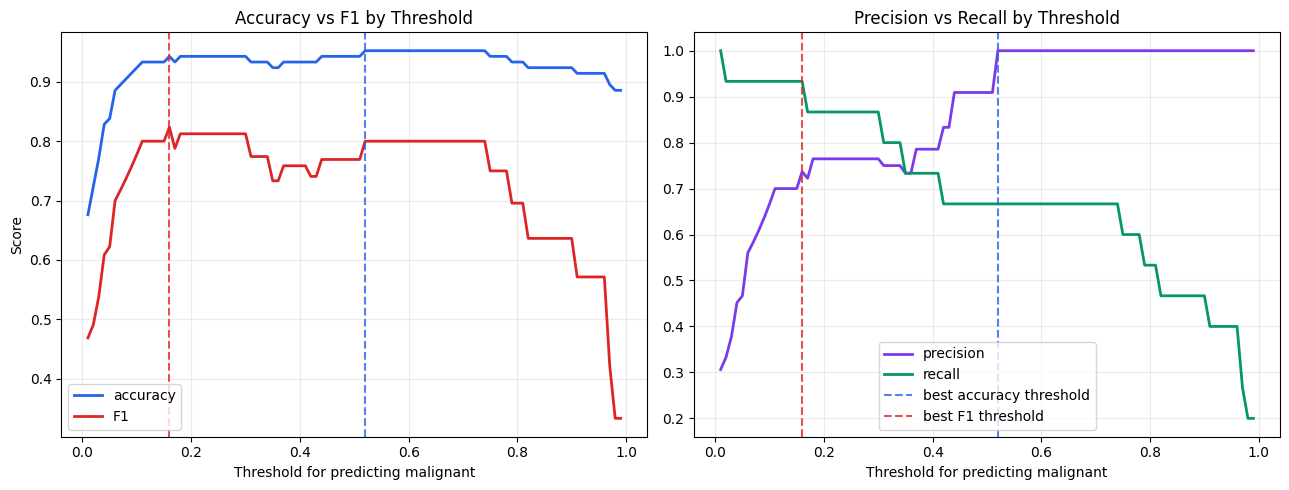

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True)

axes[0].plot(threshold_metrics["threshold"], threshold_metrics["accuracy"], label="accuracy", color="#2563EB", linewidth=2)
axes[0].plot(threshold_metrics["threshold"], threshold_metrics["f1"], label="F1", color="#DC2626", linewidth=2)
axes[0].axvline(best_accuracy_row["threshold"], color="#2563EB", linestyle="--", alpha=0.8)
axes[0].axvline(best_f1_row["threshold"], color="#DC2626", linestyle="--", alpha=0.8)
axes[0].set_title("Accuracy vs F1 by Threshold")
axes[0].set_xlabel("Threshold for predicting malignant")
axes[0].set_ylabel("Score")
axes[0].legend()

axes[1].plot(threshold_metrics["threshold"], threshold_metrics["precision"], label="precision", color="#7C3AED", linewidth=2)
axes[1].plot(threshold_metrics["threshold"], threshold_metrics["recall"], label="recall", color="#059669", linewidth=2)
axes[1].axvline(best_accuracy_row["threshold"], color="#2563EB", linestyle="--", alpha=0.8, label="best accuracy threshold")
axes[1].axvline(best_f1_row["threshold"], color="#DC2626", linestyle="--", alpha=0.8, label="best F1 threshold")
axes[1].set_title("Precision vs Recall by Threshold")
axes[1].set_xlabel("Threshold for predicting malignant")
axes[1].legend()

fig.tight_layout()
plt.show()

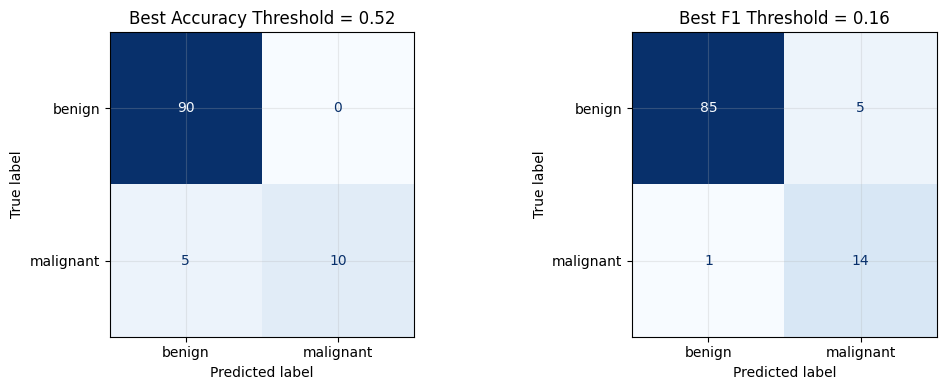

In [24]:
best_accuracy_pred = (threshold_proba >= best_accuracy_row["threshold"]).astype(int)
best_f1_pred = (threshold_proba >= best_f1_row["threshold"]).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_accuracy_pred,
    display_labels=["benign", "malignant"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0],
)
axes[0].set_title(f"Best Accuracy Threshold = {best_accuracy_row['threshold']:.2f}")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_f1_pred,
    display_labels=["benign", "malignant"],
    cmap="Blues",
    colorbar=False,
    ax=axes[1],
)
axes[1].set_title(f"Best F1 Threshold = {best_f1_row['threshold']:.2f}")

fig.tight_layout()
plt.show()

The best-accuracy threshold is conservative: it avoids false positives, but misses more malignant cases.

The best-F1 threshold predicts more positives. It may accept a few more false positives, but it catches many more true positives. For most binary classification tasks with an important positive class, that is the more useful behavior to optimize.

## 8. Main Takeaways

1. Logistic regression learns a linear score, then converts it to a probability with the sigmoid function.
2. Scaling features is useful because logistic regression coefficients and optimization are sensitive to feature scale.
3. Accuracy can be a bad metric for imbalanced binary classification: a model can get high accuracy while never predicting the positive class.
4. F1 combines precision and recall, so it is a strong default metric for almost all practical binary classification problems where the positive class matters.
5. The `0.5` probability threshold is only a default. Choose a threshold based on the metric and decision cost that match the problem.
6. Always inspect the confusion matrix together with summary metrics.